# **PyTorch Workflow Exercise**

In [1]:
import torch
from torch import nn
import matplotlib.pyplot as plt


In [2]:
# Setup device-agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"


## **Q1 Create a straight line dataset using the linear regression formula (`weight * X + bias`)**
  * Set `weight=0.4` and `bias=0.7` there should be at least 100 datapoints total.
  * Split the data into 80% training, 20% testing.
  * Plot the training and testing data so it becomes visual.

In [3]:
weight = 0.4
bias = 0.7
X = torch.arange(0, 1, 0.01).unsqueeze(dim=1)
y = weight * X + bias

In [4]:
# Split the data into training and testing
train_split = int(len(X) * 0.8)
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

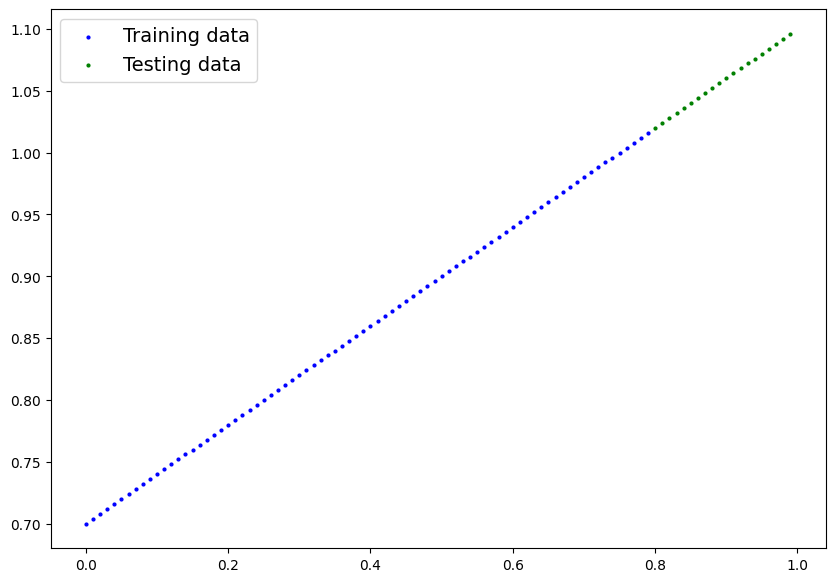

In [5]:
# Plot the training and testing data
def plot_predictions(train_data=X_train, train_labels=y_train,
                     test_data=X_test, test_labels=y_test, predictions=None):
    plt.figure(figsize=(10, 7))
    plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
    plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")
    if predictions is not None:
        plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")
    plt.legend(prop={"size": 14})
    plt.show()

plot_predictions()

## **Q2 Build a PyTorch model by subclassing `nn.Module`**
  * Inside should be a randomly initialized `nn.Parameter()` with `requires_grad=True`, one for `weights` and one for `bias`
  * Implement the `forward()` method to compute the linear regression function you used to create the dataset in Q1
  * Once you've constructed the model, make an instance of it and check its `state_dict()`
  * **Note:** If you'd like to use `nn.Linear()` instead of `nn.Parameter()` you can

In [6]:
# Create PyTorch linear regression model by subclassing nn.Module
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))
        self.bias = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.weights * x + self.bias

torch.manual_seed(42)
model_0 = LinearRegressionModel()
model_0.to(device)

LinearRegressionModel()

## **Q3 Write the training loop with `MSE` as the loss function and `Adam` as optimizer**.
  * Set the learning rate of the optimizer to be 0.05 and the parameters to optimize should be the `model.parameters()` from the model you created in Q2
  * Write a training loop to perform the appropriate training steps for 100 epochs
  * The training loop should test the model on the test dataset every 10 epochs

In [7]:
# Create the loss function and optimizer
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(params=model_0.parameters(), lr=0.05)

epochs = 100
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)



In [8]:
for epoch in range(epochs):
    model_0.train()
    y_pred = model_0(X_train)
    loss = loss_fn(y_pred, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        model_0.eval()
        with torch.inference_mode():
            test_loss = loss_fn(model_0(X_test), y_test)
        print(f"Epoch: {epoch} | Train loss: {loss:.3f} | Test loss: {test_loss:.3f}")

Epoch: 0 | Train loss: 0.356 | Test loss: 0.284
Epoch: 10 | Train loss: 0.008 | Test loss: 0.072
Epoch: 20 | Train loss: 0.028 | Test loss: 0.099
Epoch: 30 | Train loss: 0.005 | Test loss: 0.001
Epoch: 40 | Train loss: 0.003 | Test loss: 0.002
Epoch: 50 | Train loss: 0.002 | Test loss: 0.011
Epoch: 60 | Train loss: 0.000 | Test loss: 0.001
Epoch: 70 | Train loss: 0.000 | Test loss: 0.000
Epoch: 80 | Train loss: 0.000 | Test loss: 0.001
Epoch: 90 | Train loss: 0.000 | Test loss: 0.000


## **Q4 Make predictions with the trained model on the test data**
  * Visualize these predictions against the original training and testing data (**note:** you may need to make sure the predictions are *not* on the GPU if you want to use non-CUDA-enabled libraries such as matplotlib to plot).

In [9]:
# Make predictions with the model
model_0.eval()
with torch.inference_mode():
    y_preds = model_0(X_test)



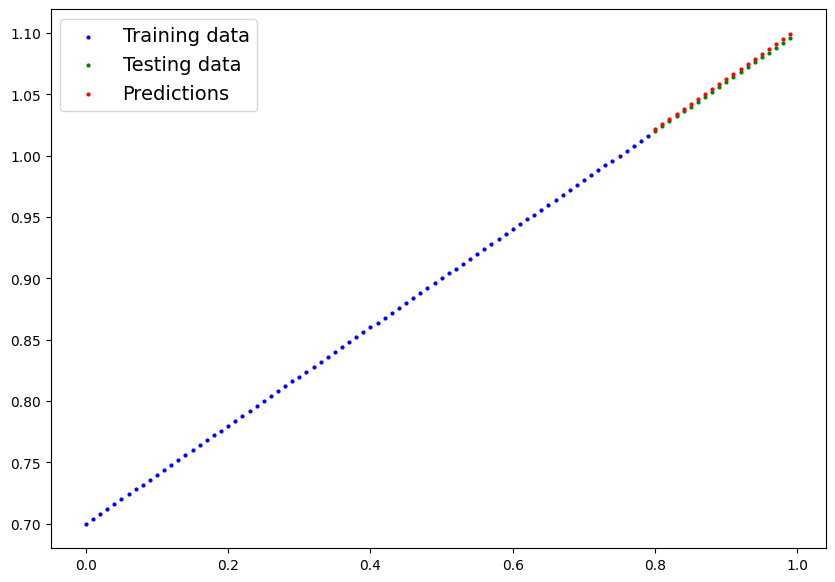

In [10]:
# Plot the predictions (these may need to be on a specific device)
plot_predictions(predictions=y_preds.cpu())

## **Q5 Save your trained model's `state_dict()` to file**
  * Create a new instance of your model class you made in 2. and load in the `state_dict()` you just saved to it.
  * Perform predictions on your test data with the loaded model and confirm they match the original model predictions from 4.

In [11]:
from pathlib import Path

MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)
MODEL_SAVE_PATH = MODEL_PATH / "02_pytorch_workflow_exercise_model.pth"

torch.save(obj=model_0.state_dict(), f=MODEL_SAVE_PATH)

loaded_model = LinearRegressionModel()
loaded_model.load_state_dict(torch.load(f=MODEL_SAVE_PATH, weights_only=True))
loaded_model.to(device)

with torch.inference_mode():
    y_preds_new = loaded_model(X_test)

y_preds == y_preds_new  # should be all True

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]], device='cuda:0')